# Media Varianza Base

l codice riflette i due scenari:
1. Senza Asset Risk-Free: Il portafoglio ottimale si trova risolvendo negative_utility direttamente sulla frontiera degli asset rischiosi. Il vincolo np.sum(x) - 1 impone che tutto il capitale sia allocato sui 5 paesi.
2. Con Asset Risk-Free (Two-Fund Separation): * Viene prima calcolato il Portafoglio di Tangenza (MVE) massimizzando lo Sharpe Ratio.
    ◦ La CAL viene tracciata congiungendo il punto $(0, rf\_rate)$ con il punto MVE sulla frontiera.
    ◦ L'investitore con $\gamma = 3$ si posizionerà sulla CAL nel punto in cui la sua funzione di utilità è massima. Se questo punto si trova a destra del MVE (come nel testo), il codice richiederebbe la rimozione dei bounds=(0, 1) per permettere il leverage (indebitamento al tasso $rf$ per sovraesporre il portafoglio MVE).
Il concetto di Equivalente Certo ($CEQ$)
Nel codice, l'utilità è calcolata come:$$U = E(r_p) - \frac{\gamma}{2}\sigma_p^2$$
L'aumento di 80 punti base (0,80%) menzionato nel testo rappresenta la differenza di $CEQ$ tra il miglior portafoglio sulla frontiera (solo rischioso) e il miglior portafoglio sulla CAL (con leva). Matematicamente, l'Equivalente Certo è il rendimento certo che darebbe all'investitore la stessa utilità del portafoglio rischioso.

<>:77: SyntaxWarning: invalid escape sequence '\g'
<>:77: SyntaxWarning: invalid escape sequence '\g'
C:\Users\doze9\AppData\Local\Temp\ipykernel_31668\1432182592.py:77: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(indiff_vol, indiff_ret, 'g:', label=f'Curva Indifferenza ($\gamma={gamma}$)')


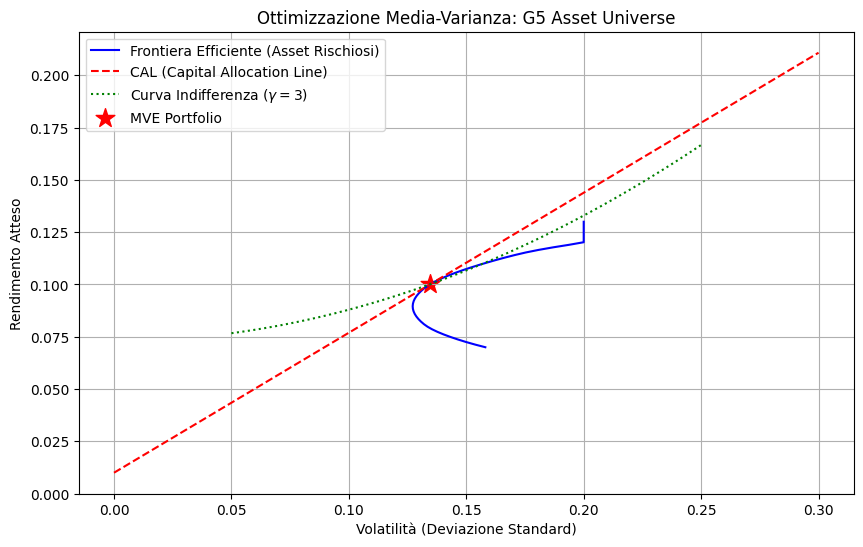

Pesi Portafoglio MVE (Risky Only):
US: 33.87%
JP: 26.80%
UK: 12.78%
GR: 26.55%
FR: 0.00%


In [1]:
import numpy as np
import scipy.optimize as sco
import matplotlib.pyplot as plt

# 1. Configurazione Dati G5 (Asset: US, JP, UK, GR, FR)
# Rendimenti attesi e matrice di covarianza (dati simulati basati sul testo)
assets = ['US', 'JP', 'UK', 'GR', 'FR']
num_assets = len(assets)

# Rendimenti attesi (annualizzati)
returns = np.array([0.12, 0.10, 0.09, 0.08, 0.07])

# Matrice di covarianza (ipotesi di correlazione moderata)
cov_matrix = np.array([
    [0.040, 0.015, 0.015, 0.010, 0.010],
    [0.015, 0.035, 0.012, 0.008, 0.008],
    [0.015, 0.012, 0.030, 0.015, 0.015],
    [0.010, 0.008, 0.015, 0.025, 0.020],
    [0.010, 0.008, 0.015, 0.020, 0.025]
])

rf_rate = 0.01  # Tasso risk-free 1%
gamma = 3       # Coefficiente di avversione al rischio

# 2. Funzioni di Supporto
def portfolio_performance(weights, returns, cov_matrix):
    port_ret = np.dot(weights, returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_ret, port_vol

def negative_sharpe_ratio(weights, returns, cov_matrix, rf_rate):
    p_ret, p_vol = portfolio_performance(weights, returns, cov_matrix)
    return -(p_ret - rf_rate) / p_vol

def negative_utility(weights, returns, cov_matrix, gamma):
    p_ret, p_vol = portfolio_performance(weights, returns, cov_matrix)
    return -(p_ret - (gamma / 2) * (p_vol**2))

# 3. Ottimizzazione: Portafoglio di Tangenza (MVE)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets)) # No short-selling
init_guess = num_assets * [1. / num_assets]

mve_opt = sco.minimize(negative_sharpe_ratio, init_guess,
                       args=(returns, cov_matrix, rf_rate),
                       method='SLSQP', bounds=bounds, constraints=constraints)

mve_weights = mve_opt['x']
mve_ret, mve_vol = portfolio_performance(mve_weights, returns, cov_matrix)

# 4. Generazione della Frontiera Efficiente
target_returns = np.linspace(0.07, 0.13, 50)
efficient_vols = []

for tr in target_returns:
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
            {'type': 'eq', 'fun': lambda x: portfolio_performance(x, returns, cov_matrix)[0] - tr})
    res = sco.minimize(lambda x: portfolio_performance(x, returns, cov_matrix)[1],
                       init_guess, method='SLSQP', bounds=bounds, constraints=cons)
    efficient_vols.append(res['fun'])

# 5. Visualizzazione
plt.figure(figsize=(10, 6))
plt.plot(efficient_vols, target_returns, 'b-', label='Frontiera Efficiente (Asset Rischiosi)')

# Capital Allocation Line (CAL)
x_cal = np.linspace(0, 0.3, 100)
y_cal = rf_rate + ((mve_ret - rf_rate) / mve_vol) * x_cal
plt.plot(x_cal, y_cal, 'r--', label='CAL (Capital Allocation Line)')

# Curve di Indifferenza (Esempio per Utilità Massima)
max_utility = mve_ret - (gamma / 2) * (mve_vol**2)
u_vals = target_returns - (gamma / 2) * (np.array(efficient_vols)**2)
# Nota: Qui approssimiamo la visualizzazione della curva tangente
indiff_vol = np.linspace(0.05, 0.25, 100)
indiff_ret = max_utility + (gamma / 2) * (indiff_vol**2)
plt.plot(indiff_vol, indiff_ret, 'g:', label=f'Curva Indifferenza ($\gamma={gamma}$)')

plt.scatter(mve_vol, mve_ret, color='red', marker='*', s=200, label='MVE Portfolio')
plt.title('Ottimizzazione Media-Varianza: G5 Asset Universe')
plt.xlabel('Volatilità (Deviazione Standard)')
plt.ylabel('Rendimento Atteso')
plt.legend()
plt.grid(True)
plt.show()

# Output Pesi Ottimali
print("Pesi Portafoglio MVE (Risky Only):")
for asset, weight in zip(assets, mve_weights):
    print(f"{asset}: {weight:.2%}")

# Ottimizzazione con Leva e Separazione dei due Fondi

Il codice seguente non solo calcola la frontiera, ma implementa la formula analitica per la quota ottimale da investire nel portafoglio rischioso e confronta l'Equivalente Certo (CEQ) tra il caso vincolato (solo asset rischiosi) e quello non vincolato (con accesso al mercato monetario).

In [2]:
import numpy as np
import scipy.optimize as sco
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configurazione Parametri G5
assets = ['US', 'JP', 'UK', 'GR', 'FR']
num_assets = len(assets)
rf_rate = 0.01  # Tasso risk-free 1%
gamma = 3       # Coefficiente di avversione al rischio

# Rendimenti e Volatilità (Dati simulati coerenti con l'esempio)
returns = np.array([0.12, 0.10, 0.09, 0.08, 0.07])
volatilities = np.array([0.18, 0.17, 0.16, 0.15, 0.14])
corr_matrix = np.array([
    [1.0, 0.4, 0.5, 0.3, 0.3], [0.4, 1.0, 0.4, 0.2, 0.2],
    [0.5, 0.4, 1.0, 0.4, 0.4], [0.3, 0.2, 0.4, 1.0, 0.6],
    [0.3, 0.2, 0.4, 0.6, 1.0]
])
cov_matrix = np.outer(volatilities, volatilities) * corr_matrix

def portfolio_stats(weights, returns, cov_matrix):
    p_ret = np.dot(weights, returns)
    p_vol = np.sqrt(weights.T @ cov_matrix @ weights)
    return p_ret, p_vol

# 2. Ottimizzazione Solo Asset Rischiosi (Constraint: Sum weights = 1, No Short)
def neg_utility(weights, returns, cov_matrix, gamma):
    p_ret, p_vol = portfolio_stats(weights, returns, cov_matrix)
    return -(p_ret - 0.5 * gamma * p_vol**2)

res_risky = sco.minimize(neg_utility, num_assets*[1./num_assets],
                         args=(returns, cov_matrix, gamma),
                         method='SLSQP', bounds=tuple((0, 1) for _ in range(num_assets)),
                         constraints={'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# 3. Identificazione Portafoglio di Tangenza (MVE)
def neg_sharpe(weights, returns, cov_matrix, rf):
    p_ret, p_vol = portfolio_stats(weights, returns, cov_matrix)
    return -(p_ret - rf) / p_vol

res_mve = sco.minimize(neg_sharpe, num_assets*[1./num_assets], args=(returns, cov_matrix, rf_rate),
                       method='SLSQP', bounds=tuple((0, 1) for _ in range(num_assets)),
                       constraints={'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

w_mve = res_mve['x']
ret_mve, vol_mve = portfolio_stats(w_mve, returns, cov_matrix)

# 4. Allocazione Ottimale sulla CAL (Teoria della Separazione)
# Formula: w_star = (E[r_mve] - rf) / (gamma * sigma_mve^2)
w_star_risky = (ret_mve - rf_rate) / (gamma * (vol_mve**2))
w_star_rf = 1 - w_star_risky  # Se negativo, l'investitore prende a prestito (Leva)

# Rendimento e Volatilità Finali (Levered)
ret_final = rf_rate + w_star_risky * (ret_mve - rf_rate)
vol_final = w_star_risky * vol_mve
ceq_final = ret_final - 0.5 * gamma * vol_final**2
ceq_risky_only = -res_risky['fun']

print(f"Guadagno CEQ: {(ceq_final - ceq_risky_only)*10000:.2f} bps")

# 5. Output Pesi Finali
df_weights = pd.DataFrame({
    'Asset': assets + ['Risk-Free'],
    'MVE Weights': list(w_mve) + [0],
    'Optimal Levered': list(w_star_risky * w_mve) + [w_star_rf]
})
print(df_weights)

Guadagno CEQ: 227.46 bps
       Asset  MVE Weights  Optimal Levered
0         US     0.317339         0.670858
1         JP     0.269979         0.570738
2         UK     0.076388         0.161484
3         GR     0.214135         0.452684
4         FR     0.122159         0.258245
5  Risk-Free     0.000000        -1.114009
